In [8]:
import xarray as xr
import numpy as np

# for year in {1940..2020}; do cdo monmean $year/ice.$year.nc $year/ice_monthly.$year.nc; done
# for year in {1941..1957}; do cdo -gtc,0 $year/ice_monthly.$year.nc $year/ice_mask.$year.nc; done

In [9]:
%%time 

YEAR_START = 1941
YEAR_FIN = 2020

PATH = "/glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_ERA5.TL319_t232_all/MONTHLY/"

PATH_raw = '/glade/derecho/scratch/mmarkina/archive/a.e30.A_ERA5.TL319_t232.2001_2010_test/cpl/hist/'
filename_raw = 'a.e30.A_ERA5.TL319_t232.2001_2010_test.cpl.hi.2011-01-01-00000.nc'
area_raw = xr.open_dataset(PATH_raw + filename_raw, engine="netcdf4")['MED_ocn_area'].isel(time=0)

R2 = 6371e3**2
area = (area_raw*R2).rename({"MED_ocn_ny": "y", "MED_ocn_nx": "x"})


land_mask = xr.open_dataset(PATH_raw + filename_raw, engine="netcdf4")['ocnImp_So_omask'].isel(time=0).rename({"ocnImp_ny": "y", "ocnImp_nx": "x"})
land_mask = land_mask.where(land_mask != 0, np.nan)

variables = {
    "latent": "ocnExp_Foxx_lat",
    "sensible": "ocnExp_Foxx_sen",
    "swnet": "ocnExp_Foxx_swnet",
    "lwnet": "ocnExp_Foxx_lwnet"
}

yearly_data = {}

for var_type, var_name in variables.items():
    if var_type not in yearly_data:
        yearly_data[var_type] = []

    for YEAR in range(YEAR_START, YEAR_FIN+1):  
        model_file = f"{PATH}{YEAR}.{var_type}.monthly.nc"
        model_ds = xr.open_dataset(model_file)
        model_var = model_ds[var_name].fillna(0)
        # ice_land_mask = xr.where(model_var == 0, np.nan, 1)

        weights = (land_mask * area)/(land_mask * area).sum(dim=("y", "x"))
        weights = weights.fillna(0)

        var_time_series = model_var.weighted(weights).mean(dim=["x", "y"])

        yearly_data[var_type].append(var_time_series.mean('time').values)
    # print(kkk)

year_range = np.arange(YEAR_START, YEAR_FIN + 1)

yearly_ds = xr.Dataset(
        {var_type: (["time"], yearly_data[var_type]) for var_type in variables.keys()},
        coords={"time": year_range}
    )

CPU times: user 37.8 s, sys: 28.7 s, total: 1min 6s
Wall time: 3min 5s


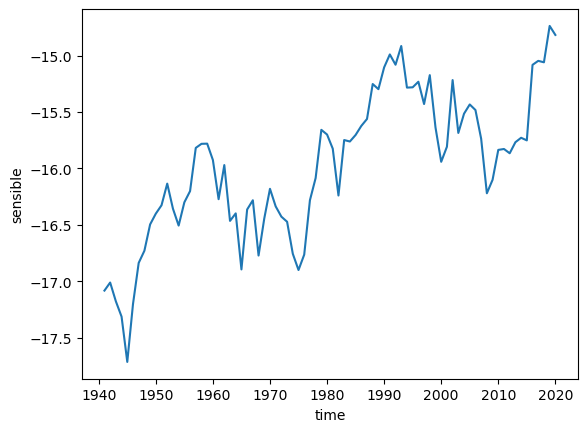

In [10]:
yearly_ds.sensible.plot()

In [11]:
output_file = f"{PATH}{YEAR_START}_{YEAR_FIN}_yearly_weighted_means_no_ice_mask.nc"
yearly_ds.to_netcdf(output_file)

print(f"Yearly time series saved to {output_file}")

Yearly time series saved to /glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_ERA5.TL319_t232_all/MONTHLY/1941_2020_yearly_weighted_means_no_ice_mask.nc
